# ML Baseline models compare with our approaches

## Settings

In [1]:
#1. Environment Initialization & Path Setup

import sys
import os
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from types import ModuleType
import builtins
import json
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, iirnotch, resample
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [2]:
# Configure environment directories
data_path = '/kaggle/input/datasets/skmrel/am-nn-28-03'
scripts_path = '/kaggle/input/datasets/skmrel/utilsskmrel'
meta_path = '/kaggle/input/datasets/skmrel/am-nn-28-03/dataset_metadata.json'

if scripts_path not in sys.path:
    sys.path.append(scripts_path)

cfg = ModuleType('config')
cfg.DATA_PATH = data_path
sys.modules['config'] = cfg

try:
    file_full_path = os.path.join(data_path, 'dataset_new.mat')
    dataset_content = sio.loadmat(file_full_path)
    if 'subject' in dataset_content:
        subjects_list = np.unique([str(s).strip() for s in dataset_content['subject']])
        print(f"Dataset status OK. Unique subjects found: {subjects_list}")
        builtins.subjects = subjects_list 
except Exception as e:
    print(f"Dataset loading error: {e}")
    builtins.subjects = []

Dataset status OK. Unique subjects found: ['A' 'B' 'C' 'J' 'M1' 'M2' 'M3' 'M4' 'M5' 'M6' 'S']


In [3]:
# Import evaluation framework utilities
try:
    from loso2_model_eval_val_1_for_np_lr import (
        get_subject_array,
        get_targets,
        get_X,
        set_seed,
        aggregate_results
    )
    from first_model_eval import (
        plot_confusion_matrix, summarize_confusions,
        build_reports, save_tables,
        print_subject_classification_reports
    )
    print("Framework evaluation utilities successfully imported.")
except Exception as e:
    print(f"Framework utility import failed: {e}")


Framework evaluation utilities successfully imported.


/kaggle/input/datasets/skmrel/utilsskmrel/first_model_eval.py:475: SyntaxWarning: invalid escape sequence '\ '
  - val subjects выбираются из eligible \ {test_subj} (могут повторяться между фолдами)


In [7]:
# Check processing units
import torch
print(f"CUDA status: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Active GPU Device: {torch.cuda.get_device_name(0)}")

CUDA status: True
Active GPU Device: Tesla T4


## Dataset building

In [8]:
# Extra-function is located in the module create_dataset_upd.py 
# 2. Signal Processing and Local Dataset Assembly (F1-F3 Pipelines)
def apply_filters(emg, fs=1000):
    """
    F2 Processing: 5-450 Hz Bandpass filter + 50 Hz Notch filter.
    Eliminates motion artifacts and powerline interference.
    """
    nyq = 0.5 * fs
    low_cutoff = 5.0 
    high_cutoff = min(450.0, nyq - 1)
    low, high = low_cutoff / nyq, high_cutoff / nyq
    b_b, a_b = butter(4, [low, high], btype='band')
    emg = filtfilt(b_b, a_b, emg, axis=0)
    b_n, a_n = iirnotch(50 / nyq, 30)
    emg = filtfilt(b_n, a_n, emg, axis=0)
    return emg

def apply_normalization(emg):
    """F3 Processing: Per-channel Z-score standardization."""
    return (emg - np.mean(emg, axis=0)) / (np.std(emg, axis=0) + 1e-8)

def process_subject_data_local(root, filename, subject_dict, use_f1, use_f2, use_f3, target_length=2500):
    file_path = os.path.join(root, filename)
    try:
        mat = loadmat(Path(file_path).as_posix(), squeeze_me=True, struct_as_record=True)
        emg_full = mat['export_EMG']
        x_full   = mat['export_X']
        y_full   = mat['export_Y']
        onpaper  = np.asarray(mat['export_OnPaper']) == 1
        trial    = np.asarray(mat['export_Trial'])
        types    = mat['export_Type']
    except Exception as e:
        print(f"Skipping file {filename} due to processing error: {e}")
        return None

    if use_f2: 
        emg_full = apply_filters(emg_full)
    if use_f3: 
        emg_full = apply_normalization(emg_full)
    
    starts = np.r_[0, np.flatnonzero(trial[1:] != trial[:-1]) + 1]
    ends = np.r_[starts[1:], len(trial)]
    
    step_back = 150 
    step_forward = 150 
    res_data = {k: [] for k in ["emg", "x", "y", "target"]}
    
    for s, e in zip(starts, ends):
        if use_f1:
            # F1 Segmentation via OnPaper trace limits
            paper_idx = np.flatnonzero(onpaper[s:e])
            if paper_idx.size == 0: 
                continue
            t_start = max(0, s + paper_idx[0] - step_back)
            t_end = min(len(trial), s + paper_idx[-1] + step_forward)
        else:
            t_start, t_end = s, e
        
        e_chunk = emg_full[t_start:t_end, :]
        if e_chunk.shape[0] < 10: 
            continue
        
        res_data["emg"].append(resample(e_chunk, target_length, axis=0))
        res_data["x"].append(resample(x_full[t_start:t_end], target_length, axis=0))
        res_data["y"].append(resample(y_full[t_start:t_end], target_length, axis=0))
        
        t_val = np.bincount(types[s:e].astype(int)).argmax() - 1
        if "15Nov07" in filename:
            t_val = t_val + 1 if t_val > 3 else t_val
        res_data["target"].append(t_val)
        
    if not res_data["target"]: 
        return None
    
    return {
        "emg": np.array(res_data["emg"]), 
        "x": np.array(res_data["x"]), 
        "y": np.array(res_data["y"]), 
        "target": np.array(res_data["target"]), 
        "subject": np.repeat(subject_dict[filename], len(res_data["target"]))
    }

def build_dataset_local(metadata_json_path, recordings_root, use_f1=False, use_f2=False, use_f3=False, target_length=2500):
    with open(metadata_json_path, "r") as f:
        meta = json.load(f)
    sub_map = {r["filename"]: r["subject"] for r in meta["recordings"]}
    parts = {k: [] for k in ["emg", "x", "y", "target", "subject"]}
    for fname in sub_map.keys():
        res = process_subject_data_local(recordings_root, fname, sub_map, use_f1, use_f2, use_f3, target_length)
        if res is not None:
            print(f"Successfully processed file: {fname}")
            for k in parts:
                parts[k].append(res[k])
    if not parts["target"]:
        raise ValueError("Data pipeline execution halted: No target segments extracted.")
    return {k: np.concatenate(v_list, axis=0) for k, v_list in parts.items()}

In [9]:
# Execute data assembly pipeline using full preprocessing steps
dataset = build_dataset_local(meta_path, data_path, use_f1=True, use_f2=True, use_f3=True)

Successfully processed file: export1_13Nov07.mat
Successfully processed file: export1_15Nov07.mat
Successfully processed file: export1_30Nov07.mat
Successfully processed file: export1_19Dec07.mat
Successfully processed file: export1_20Dec07.mat
Successfully processed file: export1_21Dec07.mat
Successfully processed file: export1_2Jan08.mat
Successfully processed file: export1_3Jan08.mat
Successfully processed file: export1_7Jan08.mat
Successfully processed file: export1_15Jan08.mat
Successfully processed file: export1_24Jan08.mat


## Modules import

In [14]:
# Classic ML models IMPORTS 
# Import the feature extractor and the model factory directly from your file
from ma_baseline_upd import (
    get_logistic_regression, 
    get_svm_baseline, 
    get_xgboost_baseline, 
    run_ml_within_subject_universal, 
    run_ml_loso_universal,
    run_simple_cnn_within_subject_universal_logged,
    run_simple_cnn_loso_universal_logged,
    local_aggregate_results, extract_emg_features
)



In [15]:
# 3.b. FEATURE EXTRACTION FROM ML_BASELINES

subject_all = get_subject_array(dataset)
y_all = get_targets(dataset, key="target")
X_raw = get_X(dataset, key="emg")

print("Extracting statistical time-domain features using ml_baselines script...")
X_features = extract_emg_features(X_raw)
print(f"Feature matrix extraction complete. Matrix dimensions: {X_features.shape}")
SEED = 42
set_seed(SEED)


Extracting statistical time-domain features using ml_baselines script...
Feature matrix extraction complete. Matrix dimensions: (5534, 32)


In [16]:
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

# Create a directory for plots if it doesn't exist
os.makedirs("plots", exist_ok=True)

# Global Data Cleaning & Filtering
# Exclude the holdout subject 'S' for a fair comparison across all models
mask = (subject_all != 'S')

y_filtered = y_all[mask]
subject_filtered = subject_all[mask]

# For classical ML models (1D Feature Vectors)
X_feat_filtered = X_features[mask]

# For 1D-CNN (3D Tensors)
X_raw_filtered = X_raw[mask]

# Axis changing: (N, 2500, 8) -> for 1D-CNN: (N, Channels, Time) -> (N, 8, 2500)
if X_raw_filtered.shape[1] != 8 and X_raw_filtered.shape[2] == 8:
    X_raw_filtered = np.transpose(X_raw_filtered, (0, 2, 1))

print("="*60)
print(f"ML Features size after correction: {X_feat_filtered.shape}")
print(f"CNN Tensor size after correction (N, C, T): {X_raw_filtered.shape}")
print("="*60)

SEED = 42

ML Features size after correction: (5086, 32)
CNN Tensor size after correction (N, C, T): (5086, 8, 2500)


# Linear Regression

In [17]:
# =====================================================================
# Logistic Regression Experiment
# =====================================================================

print("\n--- Executing Phase 1: Within-Subject Validation Setup (LogReg) ---")
lr_within_logs, lr_within_cm = run_ml_within_subject_universal(
    X_feat_filtered, y_filtered, subject_filtered, model_factory=get_logistic_regression, seed=SEED
)

# Aggregation happens automatically without manual log editing
_, _, overall_lr_within = local_aggregate_results(lr_within_logs)

print("\n--- Executing Phase 2: Inter-Subject LOSO Validation Setup (LogReg) ---")
lr_loso_logs, lr_loso_cm = run_ml_loso_universal(
    X_feat_filtered, y_filtered, subject_filtered, model_factory=get_logistic_regression, seed=SEED
)

# Aggregation for LOSO (automatically parses the 1-Test, 1-Val, N-2 Train split)
_, _, overall_lr_loso = local_aggregate_results(lr_loso_logs)

# Compilation of comparative benchmark metrics
print("\n" + "="*60)
print("COMPREHENSIVE PERFORMANCE SUMMARY: LOGISTIC REGRESSION BASELINE")
print("="*60)
print(f"Within-Subject Mean Accuracy : {overall_lr_within['acc_mean_over_seeds']:.4f}")
print(f"Within-Subject Mean F1-Macro : {overall_lr_within['f1_mean_over_seeds']:.4f}")
print("-" * 60)
print(f"LOSO Cross-Subject Mean Acc  : {overall_lr_loso['acc_mean_over_seeds']:.4f}")
print(f"LOSO Cross-Subject Mean F1   : {overall_lr_loso['f1_mean_over_seeds']:.4f}")
print("="*60)




--- Executing Phase 1: Within-Subject Validation Setup (LogReg) ---
Starting Within-Subject Validation (K=5) for ml_within...
Subj: A   | Fold 1/5 | Acc: 0.9091 | F1-Macro: 0.9092
Subj: A   | Fold 2/5 | Acc: 0.8586 | F1-Macro: 0.8553
Subj: A   | Fold 3/5 | Acc: 0.8571 | F1-Macro: 0.8588
Subj: A   | Fold 4/5 | Acc: 0.8673 | F1-Macro: 0.8667
Subj: A   | Fold 5/5 | Acc: 0.8367 | F1-Macro: 0.8392
Subj: B   | Fold 1/5 | Acc: 0.8485 | F1-Macro: 0.8493
Subj: B   | Fold 2/5 | Acc: 0.9184 | F1-Macro: 0.9153
Subj: B   | Fold 3/5 | Acc: 0.9082 | F1-Macro: 0.9073
Subj: B   | Fold 4/5 | Acc: 0.8673 | F1-Macro: 0.8671
Subj: B   | Fold 5/5 | Acc: 0.9184 | F1-Macro: 0.9205
Subj: C   | Fold 1/5 | Acc: 0.7447 | F1-Macro: 0.7424
Subj: C   | Fold 2/5 | Acc: 0.7766 | F1-Macro: 0.7650
Subj: C   | Fold 3/5 | Acc: 0.7766 | F1-Macro: 0.7766
Subj: C   | Fold 4/5 | Acc: 0.7128 | F1-Macro: 0.7192
Subj: C   | Fold 5/5 | Acc: 0.7742 | F1-Macro: 0.7725
Subj: J   | Fold 1/5 | Acc: 0.8900 | F1-Macro: 0.8865
Subj: J  

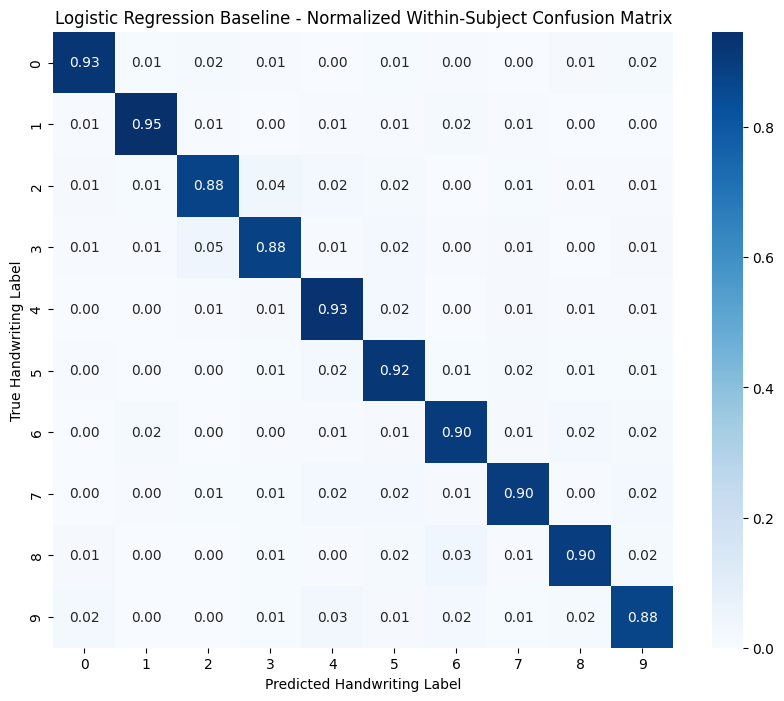

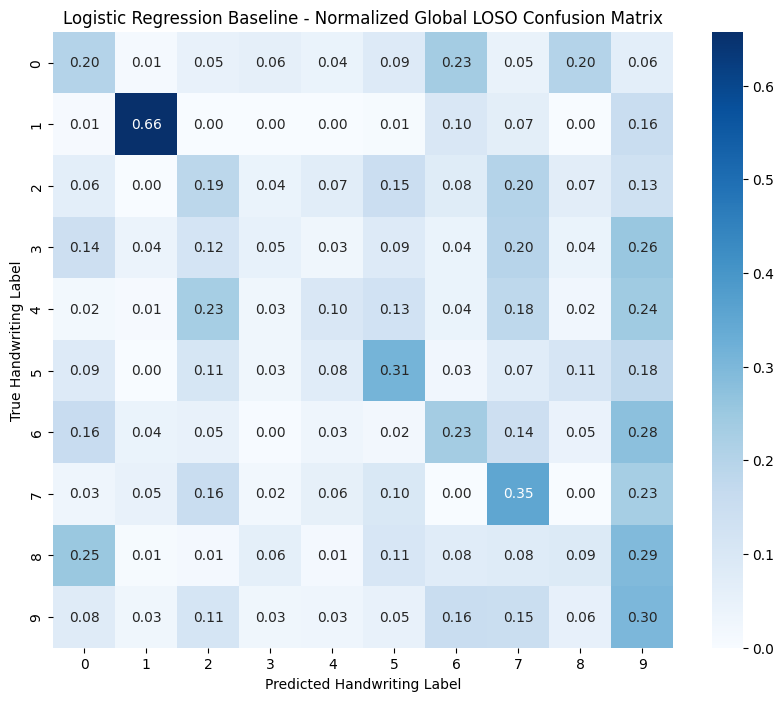

In [18]:
# 1. Normalized Confusion Matrix for WITHIN-SUBJECT
plt.figure(figsize=(10, 8))
# Normalize by rows (True Labels)
lr_within_cm_normalized = lr_within_cm.astype('float') / (lr_within_cm.sum(axis=1)[:, np.newaxis] + 1e-9)

sns.heatmap(lr_within_cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Logistic Regression Baseline - Normalized Within-Subject Confusion Matrix")
plt.ylabel("True Handwriting Label")
plt.xlabel("Predicted Handwriting Label")

# Save the Within-Subject plot
plt.savefig("plots/lr_within_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()


#2. Normalized Confusion Matrix for LOSO
plt.figure(figsize=(10, 8))
# Normalize by rows (True Labels)
lr_loso_cm_normalized = lr_loso_cm.astype('float') / (lr_loso_cm.sum(axis=1)[:, np.newaxis] + 1e-9)

sns.heatmap(lr_loso_cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Logistic Regression Baseline - Normalized Global LOSO Confusion Matrix")
plt.ylabel("True Handwriting Label")
plt.xlabel("Predicted Handwriting Label")

# Save the LOSO plot
plt.savefig("plots/lr_loso_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

# SVM experiment

In [25]:
# =====================================================================
# SVM Experiment
# =====================================================================

print("\n" + "="*60)
print("EXECUTING SVM EXPERIMENT")
print("="*60)

print("\n--- Executing Phase 1: Within-Subject Validation Setup (SVM) ---")
svm_within_logs, svm_within_cm = run_ml_within_subject_universal(
    X_feat_filtered, y_filtered, subject_filtered, model_factory=get_svm_baseline, seed=SEED
)
_, _, overall_svm_within = local_aggregate_results(svm_within_logs)

print("\n--- Executing Phase 2: Inter-Subject LOSO Validation Setup (SVM) ---")
svm_loso_logs, svm_loso_cm = run_ml_loso_universal(
    X_feat_filtered, y_filtered, subject_filtered, model_factory=get_svm_baseline, seed=SEED
)
_, _, overall_svm_loso = local_aggregate_results(svm_loso_logs)

# Compilation of comparative metrics for SVM
print("\n" + "="*60)
print("COMPREHENSIVE PERFORMANCE SUMMARY: SVM BASELINE")
print("="*60)
print(f"Within-Subject Mean Accuracy : {overall_svm_within['acc_mean_over_seeds']:.4f}")
print(f"Within-Subject Mean F1-Macro : {overall_svm_within['f1_mean_over_seeds']:.4f}")
print("-" * 60)
print(f"LOSO Cross-Subject Mean Acc  : {overall_svm_loso['acc_mean_over_seeds']:.4f}")
print(f"LOSO Cross-Subject Mean F1   : {overall_svm_loso['f1_mean_over_seeds']:.4f}")
print("="*60)




EXECUTING SVM EXPERIMENT

--- Executing Phase 1: Within-Subject Validation Setup (SVM) ---
Starting Within-Subject Validation (K=5) for ml_within...
Subj: A   | Fold 1/5 | Acc: 0.8283 | F1-Macro: 0.8319
Subj: A   | Fold 2/5 | Acc: 0.8384 | F1-Macro: 0.8362
Subj: A   | Fold 3/5 | Acc: 0.7959 | F1-Macro: 0.8001
Subj: A   | Fold 4/5 | Acc: 0.8265 | F1-Macro: 0.8207
Subj: A   | Fold 5/5 | Acc: 0.8469 | F1-Macro: 0.8493
Subj: B   | Fold 1/5 | Acc: 0.9091 | F1-Macro: 0.9058
Subj: B   | Fold 2/5 | Acc: 0.8571 | F1-Macro: 0.8535
Subj: B   | Fold 3/5 | Acc: 0.8878 | F1-Macro: 0.8862
Subj: B   | Fold 4/5 | Acc: 0.9082 | F1-Macro: 0.9056
Subj: B   | Fold 5/5 | Acc: 0.8673 | F1-Macro: 0.8668
Subj: C   | Fold 1/5 | Acc: 0.6702 | F1-Macro: 0.6600
Subj: C   | Fold 2/5 | Acc: 0.7021 | F1-Macro: 0.6971
Subj: C   | Fold 3/5 | Acc: 0.6915 | F1-Macro: 0.6774
Subj: C   | Fold 4/5 | Acc: 0.6277 | F1-Macro: 0.6346
Subj: C   | Fold 5/5 | Acc: 0.5914 | F1-Macro: 0.5765
Subj: J   | Fold 1/5 | Acc: 0.8700 | F1-

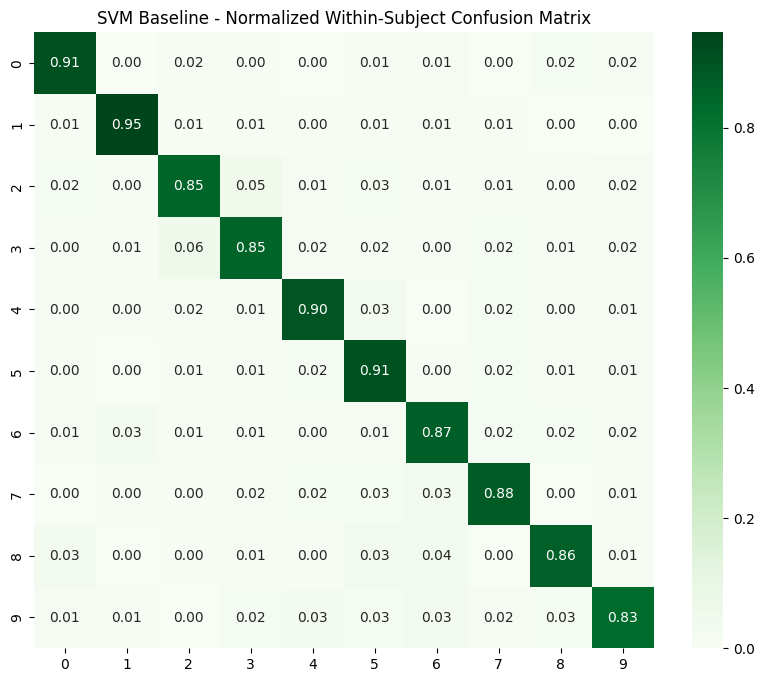

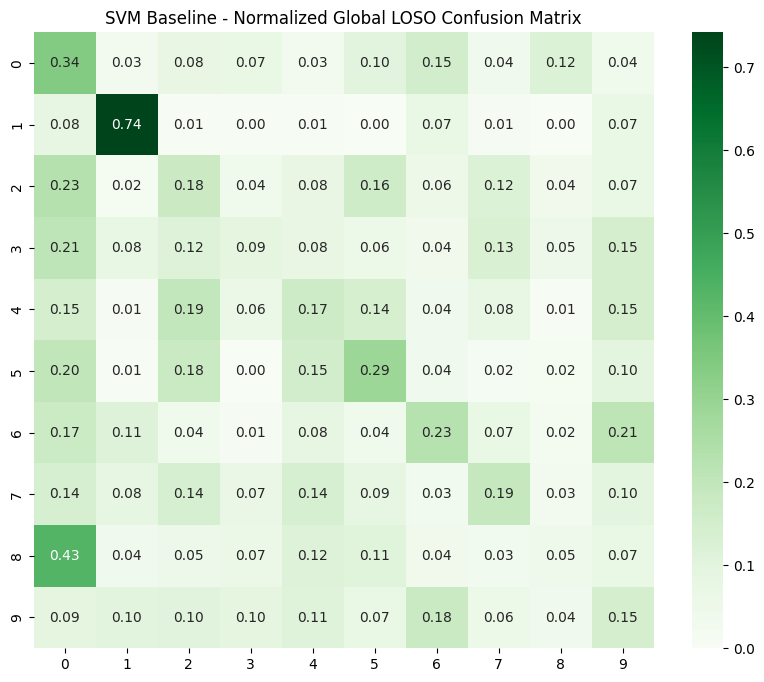

In [27]:
# --- Visualizing Confusion Matrices for SVM ---
# Within-Subject
plt.figure(figsize=(10, 8))
svm_within_cm_norm = svm_within_cm.astype('float') / (svm_within_cm.sum(axis=1)[:, np.newaxis] + 1e-9)
sns.heatmap(svm_within_cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=range(10), yticklabels=range(10))
plt.title("SVM Baseline - Normalized Within-Subject Confusion Matrix")
plt.savefig("plots/svm_within_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

# LOSO
plt.figure(figsize=(10, 8))
svm_loso_cm_norm = svm_loso_cm.astype('float') / (svm_loso_cm.sum(axis=1)[:, np.newaxis] + 1e-9)
sns.heatmap(svm_loso_cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=range(10), yticklabels=range(10))
plt.title("SVM Baseline - Normalized Global LOSO Confusion Matrix")
plt.savefig("plots/svm_loso_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

# XGboost experiments

In [28]:
# =====================================================================
# XGBoost Experiment
# =====================================================================

print("\n" + "="*60)
print("EXECUTING XGBOOST EXPERIMENT")
print("="*60)

print("\n--- Executing Phase 1: Within-Subject Validation Setup (XGB) ---")
xgb_within_logs, xgb_within_cm = run_ml_within_subject_universal(
    X_feat_filtered, y_filtered, subject_filtered, model_factory=get_xgboost_baseline, seed=SEED
)
_, _, overall_xgb_within = local_aggregate_results(xgb_within_logs)

print("\n--- Executing Phase 2: Inter-Subject LOSO Validation Setup (XGB) ---")
xgb_loso_logs, xgb_loso_cm = run_ml_loso_universal(
    X_feat_filtered, y_filtered, subject_filtered, model_factory=get_xgboost_baseline, seed=SEED
)
_, _, overall_xgb_loso = local_aggregate_results(xgb_loso_logs)

# Compilation of comparative metrics for XGBoost
print("\n" + "="*60)
print("COMPREHENSIVE PERFORMANCE SUMMARY: XGBOOST BASELINE")
print("="*60)
print(f"Within-Subject Mean Accuracy : {overall_xgb_within['acc_mean_over_seeds']:.4f}")
print(f"Within-Subject Mean F1-Macro : {overall_xgb_within['f1_mean_over_seeds']:.4f}")
print("-" * 60)
print(f"LOSO Cross-Subject Mean Acc  : {overall_xgb_loso['acc_mean_over_seeds']:.4f}")
print(f"LOSO Cross-Subject Mean F1   : {overall_xgb_loso['f1_mean_over_seeds']:.4f}")
print("="*60)




EXECUTING XGBOOST EXPERIMENT

--- Executing Phase 1: Within-Subject Validation Setup (XGB) ---
Starting Within-Subject Validation (K=5) for ml_within...
Subj: A   | Fold 1/5 | Acc: 0.8384 | F1-Macro: 0.8374
Subj: A   | Fold 2/5 | Acc: 0.8687 | F1-Macro: 0.8689
Subj: A   | Fold 3/5 | Acc: 0.7551 | F1-Macro: 0.7562
Subj: A   | Fold 4/5 | Acc: 0.8776 | F1-Macro: 0.8770
Subj: A   | Fold 5/5 | Acc: 0.8163 | F1-Macro: 0.8189
Subj: B   | Fold 1/5 | Acc: 0.8687 | F1-Macro: 0.8630
Subj: B   | Fold 2/5 | Acc: 0.8469 | F1-Macro: 0.8438
Subj: B   | Fold 3/5 | Acc: 0.8776 | F1-Macro: 0.8740
Subj: B   | Fold 4/5 | Acc: 0.8673 | F1-Macro: 0.8647
Subj: B   | Fold 5/5 | Acc: 0.8980 | F1-Macro: 0.8964
Subj: C   | Fold 1/5 | Acc: 0.7128 | F1-Macro: 0.7117
Subj: C   | Fold 2/5 | Acc: 0.6915 | F1-Macro: 0.6807
Subj: C   | Fold 3/5 | Acc: 0.7128 | F1-Macro: 0.7144
Subj: C   | Fold 4/5 | Acc: 0.6489 | F1-Macro: 0.6384
Subj: C   | Fold 5/5 | Acc: 0.6344 | F1-Macro: 0.6263
Subj: J   | Fold 1/5 | Acc: 0.8500 |

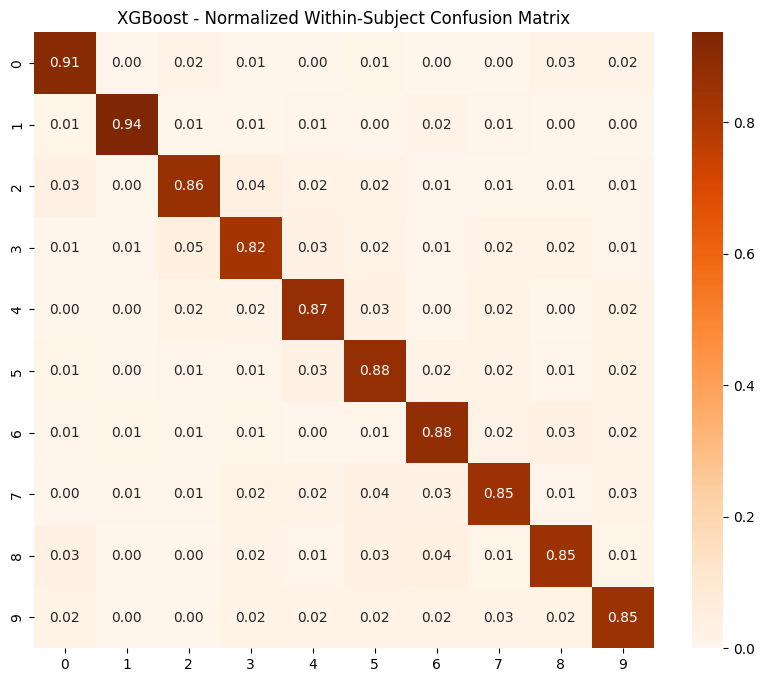

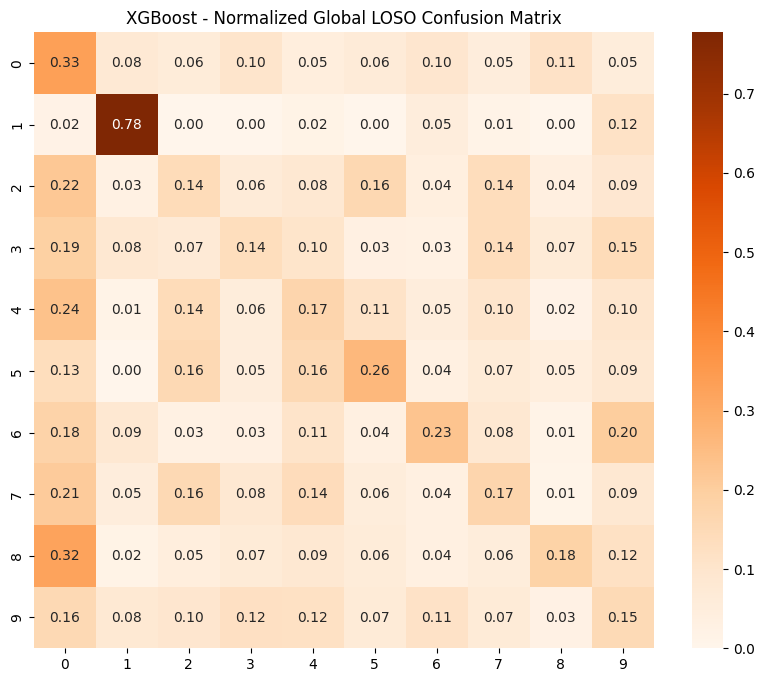

In [30]:
# Within-Subject
plt.figure(figsize=(10, 8))
xgb_within_cm_norm = xgb_within_cm.astype('float') / (xgb_within_cm.sum(axis=1)[:, np.newaxis] + 1e-9)
sns.heatmap(xgb_within_cm_norm, annot=True, fmt=".2f", cmap="Oranges", xticklabels=range(10), yticklabels=range(10))
plt.title("XGBoost - Normalized Within-Subject Confusion Matrix")
plt.savefig("plots/xgb_within_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

# LOSO
plt.figure(figsize=(10, 8))
xgb_loso_cm_norm = xgb_loso_cm.astype('float') / (xgb_loso_cm.sum(axis=1)[:, np.newaxis] + 1e-9)
sns.heatmap(xgb_loso_cm_norm, annot=True, fmt=".2f", cmap="Oranges", xticklabels=range(10), yticklabels=range(10))
plt.title("XGBoost - Normalized Global LOSO Confusion Matrix")
plt.savefig("plots/xgb_loso_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

# CNN/DL approache baseline experiment

In [31]:
# =====================================================================
# Simple 1D-CNN Baseline Experiment
# =====================================================================

RUN_EPOCHS = 150

print("\n" + "="*60)
print("EXECUTING SIMPLE 1D-CNN EXPERIMENT")
print("="*60)

# --- 1: Within-Subject ---
print("\n--- Executing Phase 1: Within-Subject Validation (Simple CNN) ---")
scnn_within_logs, scnn_within_cm = run_simple_cnn_within_subject_universal_logged(
    X_raw_filtered, y_filtered, subject_filtered, epochs=RUN_EPOCHS, seed=SEED
)
_, _, overall_scnn_within = local_aggregate_results(scnn_within_logs)

# --- 2: Inter-Subject LOSO ---
print("\n--- Executing Phase 2: Inter-Subject LOSO Validation (Simple CNN) ---")
scnn_loso_logs, scnn_loso_cm = run_simple_cnn_loso_universal_logged(
    X_raw_filtered, y_filtered, subject_filtered, epochs=RUN_EPOCHS, seed=SEED
)
_, _, overall_scnn_loso = local_aggregate_results(scnn_loso_logs)

print("\n" + "="*60)
print("PERFORMANCE SUMMARY: CORRECTED SIMPLE VANILLA CNN BASELINE")
print("="*60)
print(f"Within-Subject Mean Accuracy : {overall_scnn_within['acc_mean_over_seeds']:.4f}")
print(f"Within-Subject Mean F1-Macro : {overall_scnn_within['f1_mean_over_seeds']:.4f}")
print("-" * 60)
print(f"LOSO Cross-Subject Mean Acc  : {overall_scnn_loso['acc_mean_over_seeds']:.4f}")
print(f"LOSO Cross-Subject Mean F1   : {overall_scnn_loso['f1_mean_over_seeds']:.4f}")
print("="*60)




EXECUTING SIMPLE 1D-CNN EXPERIMENT

--- Executing Phase 1: Within-Subject Validation (Simple CNN) ---
Starting Simple CNN Within-Subject Validation (K=5) on cuda...
 -> Subject A DONE | Mean Acc: 0.8943 | Mean F1: 0.8950
 -> Subject B DONE | Mean Acc: 0.9125 | Mean F1: 0.9102
 -> Subject C DONE | Mean Acc: 0.7292 | Mean F1: 0.7220
 -> Subject J DONE | Mean Acc: 0.8732 | Mean F1: 0.8718
 -> Subject M1 DONE | Mean Acc: 0.8907 | Mean F1: 0.8891
 -> Subject M2 DONE | Mean Acc: 0.9714 | Mean F1: 0.9710
 -> Subject M3 DONE | Mean Acc: 0.9516 | Mean F1: 0.9511
 -> Subject M4 DONE | Mean Acc: 0.9490 | Mean F1: 0.9491
 -> Subject M5 DONE | Mean Acc: 0.9782 | Mean F1: 0.9781
 -> Subject M6 DONE | Mean Acc: 0.9405 | Mean F1: 0.9401
[INFO] Experiment metadata saved to cnn_within_meta.json
[INFO] Plot successfully saved to cnn_within_confusion_matrix.png

--- Executing Phase 2: Inter-Subject LOSO Validation (Simple CNN) ---

Starting Simple CNN LOSO Cross-Validation across 10 subjects on cuda...
[

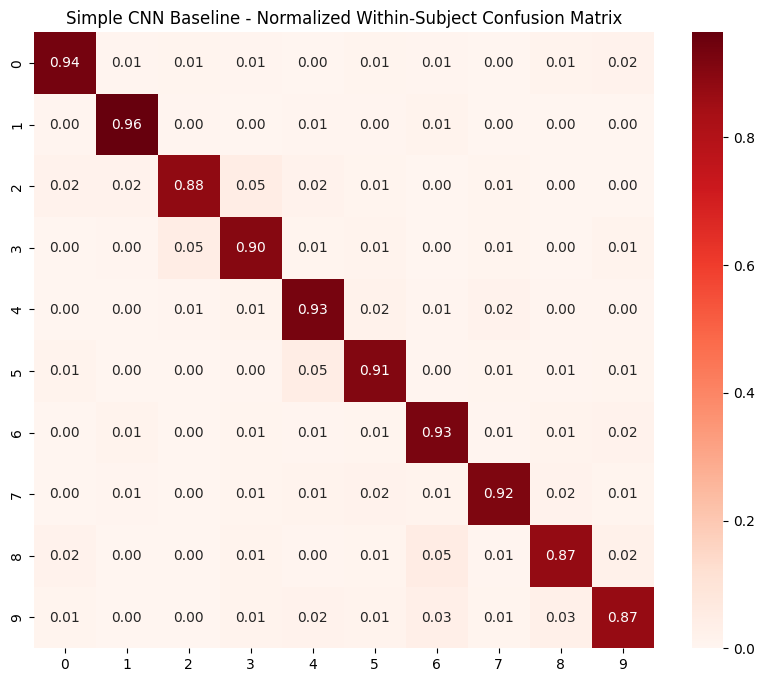

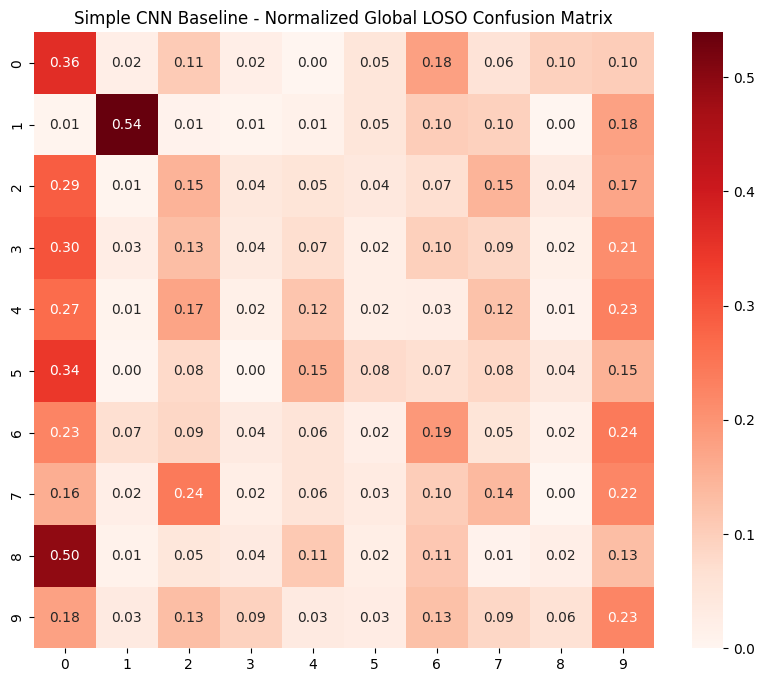

In [32]:
# Within-Subject
plt.figure(figsize=(10, 8))
scnn_within_norm = scnn_within_cm.astype('float') / (scnn_within_cm.sum(axis=1)[:, np.newaxis] + 1e-9)
sns.heatmap(scnn_within_norm, annot=True, fmt=".2f", cmap="Reds", xticklabels=range(10), yticklabels=range(10))
plt.title("Simple CNN Baseline - Normalized Within-Subject Confusion Matrix")
plt.savefig("plots/simple_cnn_within_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

# LOSO
plt.figure(figsize=(10, 8))
scnn_loso_norm = scnn_loso_cm.astype('float') / (scnn_loso_cm.sum(axis=1)[:, np.newaxis] + 1e-9)
sns.heatmap(scnn_loso_norm, annot=True, fmt=".2f", cmap="Reds", xticklabels=range(10), yticklabels=range(10))
plt.title("Simple CNN Baseline - Normalized Global LOSO Confusion Matrix")
plt.savefig("plots/simple_cnn_loso_global_cm_normalized.png", format="png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

# Our_model

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cnn_transformer_loso_v2_am_params import CNNTransformerClassifier

from loso2_model_eval_val_1_for_new_params import (
    run_within_subject_kfold,
    run_train9_val2_test1_subject_kfold5,
    aggregate_results,
    aggregate_train9_val1_test1_results,
    summarize_confusions,
    plot_confusion_matrix,
    save_tables
)


In [16]:
BASE_REPORT_DIR = "reports"
WITHIN_DIR = os.path.join(BASE_REPORT_DIR, "within_subject")
LOSO_DIR = os.path.join(BASE_REPORT_DIR, "loso")

os.makedirs(WITHIN_DIR, exist_ok=True)
os.makedirs(LOSO_DIR, exist_ok=True)




=== Running Within-Subject K-Fold ===

===== SEED 42 =====

--- Subject A ---

[Subject A] Fold 1/5 | train=393 val=99


/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.3218 acc 0.099 | val loss 2.2893 acc 0.222
Epoch 002 | train loss 2.2881 acc 0.109 | val loss 2.2347 acc 0.101
Epoch 003 | train loss 2.2232 acc 0.137 | val loss 2.1288 acc 0.232
Epoch 004 | train loss 2.1518 acc 0.196 | val loss 2.0261 acc 0.242
Epoch 005 | train loss 2.0610 acc 0.201 | val loss 1.9323 acc 0.242
Epoch 006 | train loss 1.9739 acc 0.260 | val loss 1.8579 acc 0.293
Epoch 007 | train loss 1.9467 acc 0.234 | val loss 1.8551 acc 0.222
Epoch 008 | train loss 1.8351 acc 0.257 | val loss 1.8564 acc 0.242
Epoch 009 | train loss 1.9126 acc 0.226 | val loss 1.7602 acc 0.364
Epoch 010 | train loss 1.8537 acc 0.257 | val loss 1.7863 acc 0.273
Epoch 011 | train loss 1.7891 acc 0.237 | val loss 1.7662 acc 0.202
Epoch 012 | train loss 1.8483 acc 0.247 | val loss 1.7349 acc 0.242
Epoch 013 | train loss 1.7628 acc 0.272 | val loss 1.6979 acc 0.364
Epoch 014 | train loss 1.7957 acc 0.257 | val loss 1.7295 acc 0.313
Epoch 015 | train loss 1.7299 acc 0.377 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.3590 acc 0.076 | val loss 2.2441 acc 0.172
Epoch 002 | train loss 2.2328 acc 0.160 | val loss 2.1080 acc 0.242
Epoch 003 | train loss 2.1340 acc 0.206 | val loss 1.9918 acc 0.283
Epoch 004 | train loss 2.0144 acc 0.224 | val loss 1.8870 acc 0.343
Epoch 005 | train loss 1.9346 acc 0.247 | val loss 1.8047 acc 0.343
Epoch 006 | train loss 1.9434 acc 0.260 | val loss 1.7390 acc 0.364
Epoch 007 | train loss 1.9132 acc 0.280 | val loss 1.6820 acc 0.323
Epoch 008 | train loss 1.8385 acc 0.295 | val loss 1.6555 acc 0.333
Epoch 009 | train loss 1.7373 acc 0.326 | val loss 1.6259 acc 0.364
Epoch 010 | train loss 1.7839 acc 0.303 | val loss 1.5941 acc 0.364
Epoch 011 | train loss 1.7572 acc 0.318 | val loss 1.5721 acc 0.424
Epoch 012 | train loss 1.6820 acc 0.323 | val loss 1.5518 acc 0.354
Epoch 013 | train loss 1.7384 acc 0.374 | val loss 1.5592 acc 0.364
Epoch 014 | train loss 1.6897 acc 0.382 | val loss 1.5544 acc 0.374
Epoch 015 | train loss 1.8539 acc 0.282 | val lo

...

Epoch 001 | train loss 2.2777 acc 0.081 | val loss 2.2131 acc 0.111
Epoch 002 | train loss 2.2085 acc 0.137 | val loss 2.1540 acc 0.178
Epoch 003 | train loss 2.1394 acc 0.198 | val loss 2.0699 acc 0.300
Epoch 004 | train loss 2.0646 acc 0.229 | val loss 1.9866 acc 0.233
Epoch 005 | train loss 2.0369 acc 0.254 | val loss 1.9146 acc 0.244
Epoch 006 | train loss 1.9276 acc 0.279 | val loss 1.8509 acc 0.267
Epoch 007 | train loss 1.8732 acc 0.282 | val loss 1.8008 acc 0.278
Epoch 008 | train loss 1.8035 acc 0.296 | val loss 1.7460 acc 0.389
Epoch 009 | train loss 1.8395 acc 0.324 | val loss 1.7141 acc 0.400
Epoch 010 | train loss 1.7400 acc 0.338 | val loss 1.6699 acc 0.367
Epoch 011 | train loss 1.8045 acc 0.327 | val loss 1.6624 acc 0.344
Epoch 012 | train loss 1.7653 acc 0.358 | val loss 1.6428 acc 0.389
Epoch 013 | train loss 1.7906 acc 0.349 | val loss 1.6137 acc 0.444
Epoch 014 | train loss 1.6675 acc 0.397 | val loss 1.6364 acc 0.389
Epoch 015 | train loss 1.6181 acc 0.408 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.3224 acc 0.111 | val loss 2.2514 acc 0.112
Epoch 002 | train loss 2.2325 acc 0.142 | val loss 2.1870 acc 0.135
Epoch 003 | train loss 2.1825 acc 0.209 | val loss 2.1256 acc 0.315
Epoch 004 | train loss 2.1425 acc 0.212 | val loss 2.0549 acc 0.292
Epoch 005 | train loss 2.0897 acc 0.187 | val loss 1.9833 acc 0.337
Epoch 006 | train loss 1.9866 acc 0.228 | val loss 1.8897 acc 0.303
Epoch 007 | train loss 1.9243 acc 0.273 | val loss 1.7942 acc 0.303
Epoch 008 | train loss 1.8557 acc 0.259 | val loss 1.7228 acc 0.360
Epoch 009 | train loss 1.8679 acc 0.304 | val loss 1.6780 acc 0.382
Epoch 010 | train loss 1.8070 acc 0.340 | val loss 1.6435 acc 0.393
Epoch 011 | train loss 1.8261 acc 0.329 | val loss 1.6192 acc 0.427
Epoch 012 | train loss 1.7329 acc 0.379 | val loss 1.5822 acc 0.416
Epoch 013 | train loss 1.7408 acc 0.320 | val loss 1.5503 acc 0.404
Epoch 014 | train loss 1.7643 acc 0.343 | val loss 1.5571 acc 0.461
Epoch 015 | train loss 1.6544 acc 0.390 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.2976 acc 0.120 | val loss 2.2120 acc 0.180
Epoch 002 | train loss 2.2129 acc 0.100 | val loss 2.1711 acc 0.202
Epoch 003 | train loss 2.1794 acc 0.184 | val loss 2.1389 acc 0.247
Epoch 004 | train loss 2.1299 acc 0.231 | val loss 2.0930 acc 0.169
Epoch 005 | train loss 2.1082 acc 0.220 | val loss 2.0586 acc 0.225
Epoch 006 | train loss 2.0702 acc 0.223 | val loss 1.9894 acc 0.236
Epoch 007 | train loss 1.9882 acc 0.251 | val loss 1.9361 acc 0.258
Epoch 008 | train loss 1.9566 acc 0.228 | val loss 1.8606 acc 0.281
Epoch 009 | train loss 1.9076 acc 0.279 | val loss 1.8137 acc 0.326
Epoch 010 | train loss 1.8760 acc 0.306 | val loss 1.7755 acc 0.303
Epoch 011 | train loss 1.8639 acc 0.309 | val loss 1.7394 acc 0.258
Epoch 012 | train loss 1.8867 acc 0.279 | val loss 1.7286 acc 0.292
Epoch 013 | train loss 1.8155 acc 0.340 | val loss 1.7235 acc 0.303
Epoch 014 | train loss 1.7916 acc 0.331 | val loss 1.7106 acc 0.303
Epoch 015 | train loss 1.7895 acc 0.326 | val lo

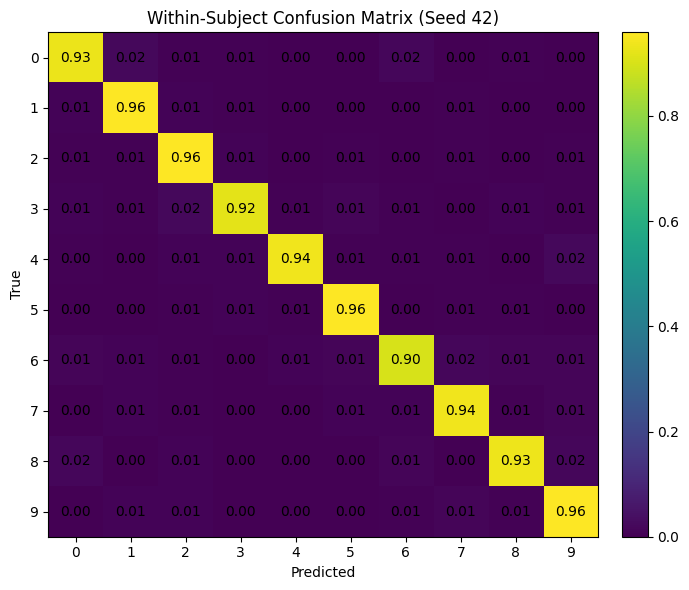

In [17]:

# ==================== 1. WITHIN-SUBJECT EVALUATION ====================
print("\n=== Running Within-Subject K-Fold ===")

results_within, conf_mats_within, pred_store_within = run_within_subject_kfold(
    dataset,
    subject_list=None,
    x_key="emg",
    y_key="target",
    n_splits=5,
    base_seed=42,
    seeds=(42,),
    batch_size=64,
    val_batch_size=128,
    epochs=200,
    lr=3e-4,
    weight_decay=1e-2,
    grad_clip=1.0,
    patience=20,
    device=None,
    model_kwargs=dict(in_ch=8, n_classes=10, d_model=64, stride_cnn=24, k_cnn=15),
)

# --- aggregation and saving Within-Subject ---
df_within, by_subj_within, by_seed_within, overall_within = aggregate_results(results_within)

# fold_results.csv, subject_results.csv и seed_results.csv
save_tables(df_within, by_subj_within, by_seed_within, out_dir=WITHIN_DIR)

with open(os.path.join(WITHIN_DIR, "overall_summary.txt"), "w", encoding="utf-8") as f:
    f.write("=== Within-Subject Overall Metrics ===\n")
    for k, v in overall_within.items():
        f.write(f"{k}: {v}\n")
print(f"[OK] Saved text summary to: {WITHIN_DIR}/overall_summary.txt")

print("=== Generating Within-Subject Confusion Matrix ===")
cm_within_all = summarize_confusions(conf_mats_within, seed=42)

fig, ax = plot_confusion_matrix(
    cm_within_all, 
    title="Within-Subject Confusion Matrix (Seed 42)",
    savepath=os.path.join(WITHIN_DIR, "confusion_matrix_within.png")
)
plt.show()
plt.close(fig)




=== Running LOSO Cross-Validation ===

===== SEED 42 =====

=== Fold 1/10 | VAL: [np.str_('M2')] | TEST: M4 ===


/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.2572 acc 0.152 | val loss 2.0763 acc 0.194
Epoch 002 | train loss 2.1848 acc 0.193 | val loss 2.0501 acc 0.263
Epoch 003 | train loss 2.1624 acc 0.198 | val loss 2.0076 acc 0.308
Epoch 004 | train loss 2.0710 acc 0.253 | val loss 1.8726 acc 0.392
Epoch 005 | train loss 1.8944 acc 0.347 | val loss 1.5547 acc 0.471
Epoch 006 | train loss 1.7486 acc 0.410 | val loss 1.3764 acc 0.584
Epoch 007 | train loss 1.5487 acc 0.497 | val loss 1.2015 acc 0.663
Epoch 008 | train loss 1.4383 acc 0.539 | val loss 1.0539 acc 0.694
Epoch 009 | train loss 1.4006 acc 0.545 | val loss 1.1031 acc 0.671
Epoch 010 | train loss 1.3307 acc 0.560 | val loss 0.9359 acc 0.720
Epoch 011 | train loss 1.2265 acc 0.611 | val loss 0.8574 acc 0.727
Epoch 012 | train loss 1.1425 acc 0.638 | val loss 0.7784 acc 0.755
Epoch 013 | train loss 1.0632 acc 0.664 | val loss 0.7393 acc 0.747
Epoch 014 | train loss 1.0586 acc 0.662 | val loss 0.6643 acc 0.792
Epoch 015 | train loss 0.9747 acc 0.693 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.2266 acc 0.172 | val loss 1.9686 acc 0.284
Epoch 002 | train loss 2.1420 acc 0.212 | val loss 1.9208 acc 0.356
Epoch 003 | train loss 2.0959 acc 0.240 | val loss 1.8484 acc 0.360
Epoch 004 | train loss 2.0143 acc 0.290 | val loss 1.5037 acc 0.576
Epoch 005 | train loss 1.7642 acc 0.399 | val loss 1.1577 acc 0.704
Epoch 006 | train loss 1.5843 acc 0.469 | val loss 1.0433 acc 0.718
Epoch 007 | train loss 1.4901 acc 0.505 | val loss 0.9253 acc 0.747
Epoch 008 | train loss 1.4368 acc 0.524 | val loss 0.8442 acc 0.778
Epoch 009 | train loss 1.3234 acc 0.575 | val loss 0.7271 acc 0.867
Epoch 010 | train loss 1.2955 acc 0.582 | val loss 0.7089 acc 0.832
Epoch 011 | train loss 1.1003 acc 0.640 | val loss 0.6110 acc 0.859
Epoch 012 | train loss 1.1126 acc 0.649 | val loss 0.5693 acc 0.874
Epoch 013 | train loss 1.1102 acc 0.640 | val loss 0.5335 acc 0.880
Epoch 014 | train loss 1.0547 acc 0.665 | val loss 0.5127 acc 0.899
Epoch 015 | train loss 1.0018 acc 0.671 | val lo

...

Epoch 001 | train loss 2.2448 acc 0.156 | val loss 2.0437 acc 0.257
Epoch 002 | train loss 2.1872 acc 0.198 | val loss 2.0171 acc 0.253
Epoch 003 | train loss 2.1521 acc 0.212 | val loss 1.9814 acc 0.267
Epoch 004 | train loss 2.0595 acc 0.274 | val loss 1.6446 acc 0.418
Epoch 005 | train loss 1.8035 acc 0.387 | val loss 1.2713 acc 0.520
Epoch 006 | train loss 1.6970 acc 0.428 | val loss 1.1501 acc 0.608
Epoch 007 | train loss 1.5784 acc 0.487 | val loss 1.0705 acc 0.661
Epoch 008 | train loss 1.4821 acc 0.518 | val loss 1.0005 acc 0.720
Epoch 009 | train loss 1.3934 acc 0.550 | val loss 0.9301 acc 0.739
Epoch 010 | train loss 1.3076 acc 0.576 | val loss 0.8386 acc 0.796
Epoch 011 | train loss 1.2827 acc 0.578 | val loss 0.7433 acc 0.820
Epoch 012 | train loss 1.1471 acc 0.630 | val loss 0.7069 acc 0.802
Epoch 013 | train loss 1.1439 acc 0.628 | val loss 0.6694 acc 0.824
Epoch 014 | train loss 1.0639 acc 0.656 | val loss 0.6311 acc 0.831
Epoch 015 | train loss 1.0365 acc 0.672 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.2458 acc 0.162 | val loss 2.2471 acc 0.170
Epoch 002 | train loss 2.1545 acc 0.212 | val loss 2.2468 acc 0.176
Epoch 003 | train loss 2.0966 acc 0.255 | val loss 2.1960 acc 0.166
Epoch 004 | train loss 1.9886 acc 0.298 | val loss 2.0568 acc 0.174
Epoch 005 | train loss 1.8512 acc 0.353 | val loss 1.9000 acc 0.321
Epoch 006 | train loss 1.6720 acc 0.433 | val loss 1.7520 acc 0.408
Epoch 007 | train loss 1.4889 acc 0.508 | val loss 1.6809 acc 0.416
Epoch 008 | train loss 1.4187 acc 0.539 | val loss 1.4844 acc 0.477
Epoch 009 | train loss 1.2801 acc 0.592 | val loss 1.5252 acc 0.504
Epoch 010 | train loss 1.2246 acc 0.610 | val loss 1.3668 acc 0.523
Epoch 011 | train loss 1.1068 acc 0.647 | val loss 1.2775 acc 0.582
Epoch 012 | train loss 1.0740 acc 0.660 | val loss 1.2889 acc 0.582
Epoch 013 | train loss 1.0293 acc 0.679 | val loss 1.1578 acc 0.628
Epoch 014 | train loss 1.0074 acc 0.676 | val loss 1.2251 acc 0.584
Epoch 015 | train loss 0.9459 acc 0.702 | val lo

/kaggle/input/datasets/skmrel/utilsskmrel/cnn_transformer_loso_v2_am_params.py:369: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 001 | train loss 2.2362 acc 0.165 | val loss 2.1291 acc 0.175
Epoch 002 | train loss 2.1764 acc 0.195 | val loss 2.1292 acc 0.235
Epoch 003 | train loss 2.1128 acc 0.228 | val loss 2.0706 acc 0.167
Epoch 004 | train loss 1.9646 acc 0.311 | val loss 1.9085 acc 0.304
Epoch 005 | train loss 1.7131 acc 0.427 | val loss 1.7462 acc 0.394
Epoch 006 | train loss 1.4761 acc 0.523 | val loss 1.7866 acc 0.443
Epoch 007 | train loss 1.3829 acc 0.558 | val loss 1.8798 acc 0.431
Epoch 008 | train loss 1.2895 acc 0.594 | val loss 1.8069 acc 0.475
Epoch 009 | train loss 1.1788 acc 0.623 | val loss 1.9235 acc 0.465
Epoch 010 | train loss 1.1159 acc 0.647 | val loss 1.8187 acc 0.477
Epoch 011 | train loss 1.0150 acc 0.675 | val loss 1.8557 acc 0.443
Epoch 012 | train loss 1.0355 acc 0.671 | val loss 1.9105 acc 0.455
Epoch 013 | train loss 0.9312 acc 0.698 | val loss 1.7469 acc 0.491
Epoch 014 | train loss 0.9806 acc 0.681 | val loss 1.9729 acc 0.479
Epoch 015 | train loss 0.8544 acc 0.724 | val lo

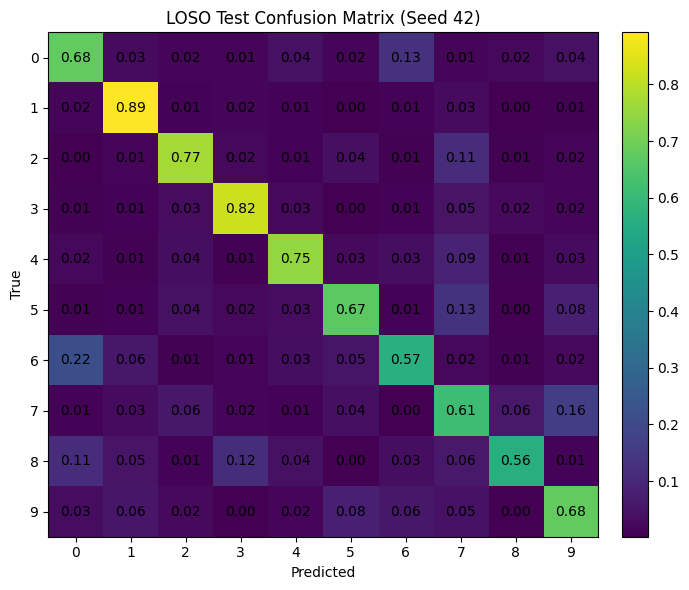


[FINISHED] All logs, tables, and charts are stored successfully.


In [18]:


# ==================== 2. LOSO EVALUATION ====================
print("\n=== Running LOSO Cross-Validation ===")

results, conf_mats, pred_store = run_train9_val2_test1_subject_kfold5(
    dataset,
    exclude_holdout_subject=("S"),
    n_folds=10,
    fold_seed=123,
    seeds=(42,),
    x_key="emg",
    y_key="target",
    batch_size=64,
    val_batch_size=128,
    test_batch_size=256,
    epochs=200,
    lr=3e-4,
    weight_decay=1e-2,
    grad_clip=1.0,
    patience=20,
    device=None,
    model_kwargs=dict(in_ch=8, n_classes=10, d_model=64, stride_cnn=24, k_cnn=15),
)

# --- agregation & saving df LOSO ---
df_loso, by_test_subject, by_seed_loso, overall_loso = aggregate_train9_val1_test1_results(results)

# LOSO
df_loso.to_csv(os.path.join(LOSO_DIR, "fold_results_loso.csv"), index=False)
by_test_subject.to_csv(os.path.join(LOSO_DIR, "test_subject_results_loso.csv"), index=False)
by_seed_loso.to_csv(os.path.join(LOSO_DIR, "seed_results_loso.csv"), index=False)
print(f"[OK] Saved LOSO tables to: {LOSO_DIR}/")

# Loging and text res LOSO into 
with open(os.path.join(LOSO_DIR, "overall_summary_loso.txt"), "w", encoding="utf-8") as f:
    f.write("=== LOSO Overall Metrics ===\n")
    for k, v in overall_loso.items():
        f.write(f"{k}: {v}\n")
    f.write("\n=== Metrics By Seed ===\n")
    f.write(by_seed_loso.to_string())
print(f"[OK] Saved text summary to: {LOSO_DIR}/overall_summary_loso.txt")

print("=== Generating LOSO Confusion Matrix ===")
cm_loso_test = np.zeros((10, 10), dtype=np.int64)
for (seed, fold, split, subj), cm in conf_mats.items():
    if split == "test" and seed == 42:
        cm_loso_test += cm

fig_loso, ax_loso = plot_confusion_matrix(
    cm_loso_test, 
    title="LOSO Test Confusion Matrix (Seed 42)",
    savepath=os.path.join(LOSO_DIR, "confusion_matrix_loso.png")
)
plt.show()
plt.close(fig_loso)

print("\n[FINISHED] All logs, tables, and charts are stored successfully.")